In [70]:
import json
import os
import re
from pathlib import Path

import pandas as pd

RUN_DIR = Path("../../runs/bomberman_ppo_20260914_182311")
LOG_DIR = RUN_DIR / "logs"


In [71]:
def eval_from_checkpoints(run_dir):
    rows = []
    for meta_path in sorted((run_dir / "checkpoints").glob("checkpoint_*/metadata.json")):
        meta = json.loads(meta_path.read_text())
        suite = meta.get("eval_suite") or {}
        for case, value in suite.items():
            name = case.split(".")[1] if case.startswith("agent_code.") else case
            row = {"timesteps": meta["timesteps"], "case": name}
            if isinstance(value, dict):
                row.update(value)
            else:
                row["reward"] = value
            rows.append(row)
    return pd.DataFrame(rows)


checkpoint_df = eval_from_checkpoints(RUN_DIR)
checkpoint_df


,timesteps,case,reward
0,1048576,rule_based_agent,-3.542667
1,1048576,coin_collector_agent,-0.647417
2,1048576,peaceful_agent,0.000000
3,1048576,gen_coin-heaven_0opp,4.865000
4,1048576,gen_empty_0opp,0.000000
...,...,...,...
1003,150208512,peaceful_agent,11.000000
1004,150208512,gen_coin-heaven_0opp,32.700000
1005,150208512,gen_empty_0opp,0.000000
1006,150208512,gen_classic_1opp,9.300000


In [72]:
LINE = re.compile(
    r"eval (?:vs (?P<bot>\w+)(?: \([^)]*\))?|generalization \[(?P<gen>[^\]]+)\]):\s*(?P<body>.*?)\s*\(n=(?P<n>\d+)\)"
)
FIELD = re.compile(r"(?P<key>score|win|survived|length|reward)\s+(?P<value>[-+]?\d+(?:\.\d+)?)%?")
TIMESTEP = re.compile(r"Eval game finished at\s*(?P<timesteps>\d+)\s*timesteps")


def parse_eval_line(line):
    match = LINE.search(line)
    if not match:
        return None
    case = match.group("bot") or "gen_" + match.group("gen").replace(", ", "_").replace(" ", "")
    body = match.group("body")
    fields = {m.group("key"): float(m.group("value")) for m in FIELD.finditer(body)}
    if not fields:
        fields = {"reward": float(body)}
    for key in ("win", "survived"):
        if key in fields:
            fields[key] /= 100.0
    return case, fields, int(match.group("n"))


def eval_from_logs(log_dir):
    rows = []
    for log_path in sorted(log_dir.glob("*.out")):
        pending = []
        for line in log_path.read_text(errors="replace").splitlines():
            parsed = parse_eval_line(line)
            if parsed:
                pending.append(parsed)
                continue
            done = TIMESTEP.search(line)
            if done and pending:
                for case, fields, n in pending:
                    rows.append({"timesteps": int(done.group("timesteps")), "case": case, "n": n,
                                 "log_file": log_path.name, **fields})
                pending = []
    return pd.DataFrame(rows).drop_duplicates(["timesteps", "case"]).sort_values(["timesteps", "case"])


log_df = eval_from_logs(LOG_DIR) if LOG_DIR.exists() else pd.DataFrame()
log_df


,timesteps,case,n,log_file,reward
1,1048576,coin_collector_agent,10,bomberman-ppo-91.out,-2.43
5,1048576,gen_classic_1opp,10,bomberman-ppo-91.out,-4.42
6,1048576,gen_classic_2opp,10,bomberman-ppo-91.out,-5.10
3,1048576,gen_coin-heaven_0opp,10,bomberman-ppo-91.out,4.30
4,1048576,gen_empty_0opp,10,bomberman-ppo-91.out,0.00
...,...,...,...,...,...
944,140509184,gen_classic_2opp,10,bomberman-ppo-92.out,6.30
941,140509184,gen_coin-heaven_0opp,10,bomberman-ppo-92.out,38.90
942,140509184,gen_empty_0opp,10,bomberman-ppo-92.out,0.00
940,140509184,peaceful_agent,10,bomberman-ppo-92.out,15.60


In [73]:
df = checkpoint_df if len(checkpoint_df) else log_df
metric = "score" if "score" in df.columns and df["score"].notna().any() else "reward"
table = df.pivot_table(index="timesteps", columns="case", values=metric)
table


case,coin_collector_agent,gen_classic_1opp,gen_classic_2opp,gen_coin-heaven_0opp,gen_empty_0opp,peaceful_agent,rule_based_agent
timesteps,,,,,,,
1048576,-0.647417,-3.683500,-4.716917,4.865,0.0,0.0,-3.542667
2097152,-1.853083,-3.987250,-4.000833,4.880,0.0,0.0,-5.079083
3145728,-0.682083,-4.343250,-5.684833,5.790,0.0,0.0,-4.247167
4194304,-2.490083,-3.016833,-3.763083,8.385,0.0,0.0,-5.105250
5242880,-4.443083,-3.621833,-3.592583,9.575,0.0,0.0,-2.713333
...,...,...,...,...,...,...,...
146800640,4.300000,9.300000,4.000000,38.100,0.0,15.2,6.700000
147849216,5.700000,8.900000,6.100000,38.300,0.0,9.8,7.000000
148897792,8.200000,6.800000,4.600000,37.800,0.0,14.4,4.600000


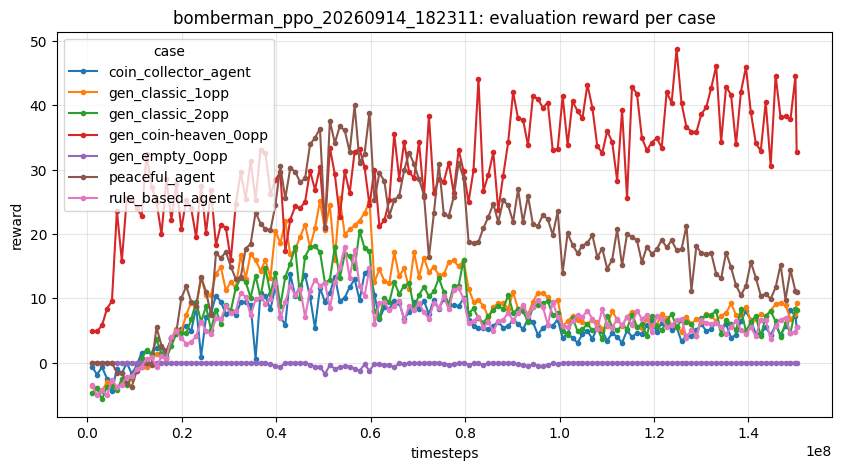

In [74]:
import matplotlib.pyplot as plt

ax = table.plot(figsize=(10, 5), marker=".")
ax.set_xlabel("timesteps")
ax.set_ylabel(metric)
ax.set_title(f"{RUN_DIR.name}: evaluation {metric} per case")
ax.grid(alpha=0.3)
plt.show()
